In [23]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from nd2.utils.plot import get_fig

data = json.load(open('./data/hetero_edge/hetero_edge_kuramoto.json', 'r'))
A = np.array(data['A'])
G = np.array(data['G'])
w = np.array(data['w'])
omega = np.array(data['omega'])
result = pd.read_json('./result/hetero_edge.json', lines=True)

/tmp/ipykernel_1728682/3905269764.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result2, x='name', y='time', ax=ax, palette='Set2', capsize=0.1)
/tmp/ipykernel_1728682/3905269764.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unweighted', 'Weighted'])


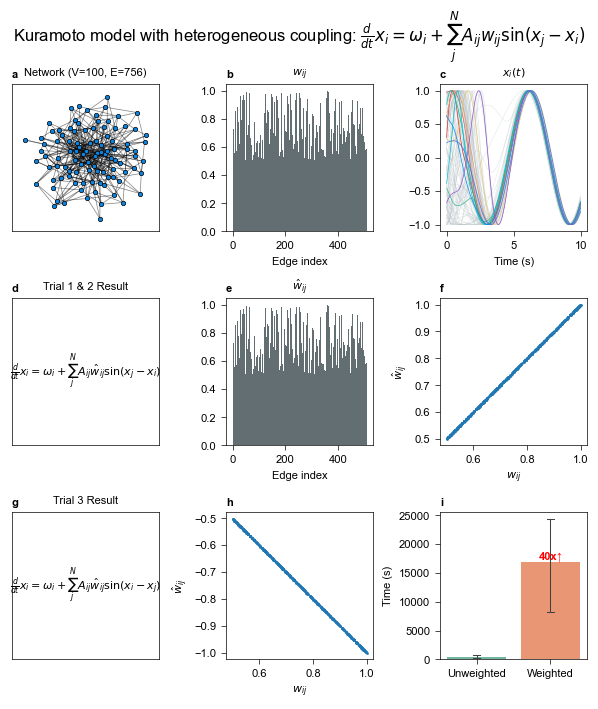

In [26]:
from matplotlib.colors import LinearSegmentedColormap

fi, fig, axes = get_fig(3, 3, FW=18, LM=6, TM=8, BM=6, RM=6, HS=6, VS=6, fontsize=8, dpi=100)

ax = axes[0]
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='k', ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=10, linewidths=0.5, node_color='#0984e3', edgecolors='k', ax=ax)
ax.set_title(f'Network (V={G.number_of_nodes()}, E={2*G.number_of_edges()})', fontsize=8)

# ax = axes[1]
# ax.bar(np.arange(len(omega)), omega, color='#636e72', width=1.0)
# ax.set_title(r'$\omega_i$')
# ax.set_xlabel('Node index')

ax = axes[1]
ax.bar(np.arange(len(w)), w, color='#636e72', width=1.0)
ax.set_title(r'$w_{ij}$')
ax.set_xlabel('Edge index')

ax = axes[2]
N = 10
time = np.arange(1000) * 0.01
cmap = LinearSegmentedColormap.from_list('my_hsv', ['#d63031', '#e17055', '#fdcb6e', '#00b894', '#00cec9', '#0984e3' ,'#6c5ce7', '#e84393'])
for i in range(N):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=cmap(i/N))
for i in range(N, A.shape[0]):
    ax.plot(time, np.sin(data['x'])[:, i], color='#b2bec3', alpha=0.3, zorder=-100000)
ax.set_title('$x_i(t)$')
ax.set_xlabel('Time (s)')

ax = axes[3]
ax.text(0.5, 0.5, r'$\frac{d}{dt}x_i = \omega_i + \sum_j^N A_{ij} \hat{w}_{ij}\sin(x_j - x_i)$', fontsize=8, ha='center', va='center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Trial 1 & 2 Result')

ax = axes[4]
w2 = np.array(result.loc[0, 'result'][4])
ax.bar(np.arange(len(w2)), w2, color='#636e72', width=1.0)
ax.set_title(r'$\hat{w}_{ij}$')
ax.set_xlabel('Edge index')

ax = axes[5]
ax.scatter(w, w2, s=1)
ax.set_xlabel(r'$w_{ij}$')
ax.set_ylabel(r'$\hat{w}_{ij}$')


ax = axes[6]
ax.text(0.5, 0.5, r'$\frac{d}{dt}x_i = \omega_i + \sum_j^N A_{ij} \hat{w}_{ij}\sin(x_i - x_j)$', fontsize=8, ha='center', va='center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Trial 3 Result')

# ax = axes[7]
# w2 = np.array(result.loc[1, 'result'][4])
# ax.bar(np.arange(len(w2)), w2, color='#636e72', width=1.0)
# ax.set_title(r'$\hat{w}_{ij}$')
# ax.set_xlabel('Edge index')

ax = axes[7]
w2 = np.array(result.loc[2, 'result'][4])
ax.scatter(w, w2, s=1)
ax.set_xlabel(r'$w_{ij}$')
ax.set_ylabel(r'$\hat{w}_{ij}$')

ax = axes[8]
result2 = pd.concat([
    pd.DataFrame([
        ('Unweighted Kuramoto', 145),
        ('Unweighted Kuramoto', 835),
        ('Unweighted Kuramoto', 267),
    ], columns=['name', 'time']),
    result[['name', 'time']]
])
# result2 = result.loc[::-1]
sns.barplot(data=result2, x='name', y='time', ax=ax, palette='Set2', capsize=0.1)
ax.set_xticklabels(['Unweighted', 'Weighted'])
ax.set_xlabel('')
ax.set_ylabel('Time (s)')
ratio = result2.groupby('name')['time'].mean().values
ax.text(1.0, ratio[1]*1.0, f'{ratio[1]/ratio[0]-1:.0f}x↑', color='red', weight='bold', fontsize=8, ha='center', va='bottom')



# ax = axes[9]
# ax.text(0.5, 0.5, r'$\frac{d}{dt}x_i = \omega_i + \sum_j \hat{w}_{ij}\sin(x_i - x_j)$', fontsize=8, ha='center', va='center')
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_title('Trial 3 Result')

# ax = axes[10]
# w2 = np.array(result.loc[2, 'result'][4])
# ax.bar(np.arange(len(w2)), w2, color='#636e72', width=1.0)
# ax.set_title(r'$\hat{w}_{ij}$')
# ax.set_xlabel('Edge index')

# ax = axes[11]
# ax.scatter(w, w2, s=1)
# ax.set_xlabel(r'$w_{ij}$')
# ax.set_ylabel(r'$\hat{w}_{ij}$')

fig.suptitle(r'Kuramoto model with heterogeneous coupling: $\frac{d}{dt}x_i = \omega_i + \sum_j^N A_{ij} w_{ij}\sin(x_j - x_i)$', fontsize=12)

for idx, ax in enumerate(axes):
    ax.text(0, 1.03, chr(ord('a') + idx), fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

fig.savefig('./plot/hetero_edge/hetero_edge_kuramoto_result.pdf', dpi=300, bbox_inches='tight')

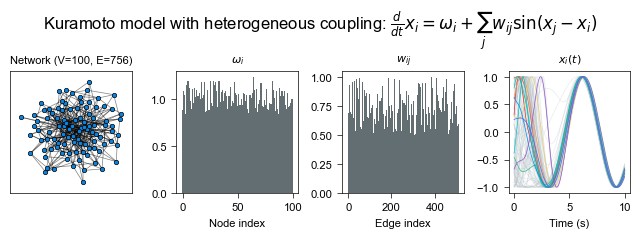

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap

fi, fig, axes = get_fig(1, 4, FW=18, LM=4, TM=6, BM=4, RM=4, fontsize=8, dpi=100)

ax = axes[0]
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='k', ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=10, linewidths=0.5, node_color='#0984e3', edgecolors='k', ax=ax)
ax.set_title(f'Network (V={G.number_of_nodes()}, E={2*G.number_of_edges()})', fontsize=8)

ax = axes[1]
ax.bar(np.arange(len(omega)), omega, color='#636e72', width=1.0)
ax.set_title(r'$\omega_i$')
ax.set_xlabel('Node index')

ax = axes[2]
ax.bar(np.arange(len(w)), w, color='#636e72', width=1.0)
ax.set_title(r'$w_{ij}$')
ax.set_xlabel('Edge index')

ax = axes[3]
N = 10
time = np.arange(1000) * 0.01
cmap = LinearSegmentedColormap.from_list('my_hsv', ['#d63031', '#e17055', '#fdcb6e', '#00b894', '#00cec9', '#0984e3' ,'#6c5ce7', '#e84393'])
for i in range(N):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=cmap(i/N))
for i in range(N, A.shape[0]):
    ax.plot(time, np.sin(data['x'])[:, i], color='#b2bec3', alpha=0.3, zorder=-100000)
ax.set_title('$x_i(t)$')
ax.set_xlabel('Time (s)')

fig.suptitle(r'Kuramoto model with heterogeneous coupling: $\frac{d}{dt}x_i = \omega_i + \sum_j w_{ij}\sin(x_j - x_i)$', fontsize=12)

fig.savefig('./plot/hetero_edge/hetero_edge_kuramoto_demo.pdf', dpi=300, bbox_inches='tight')

<>:28: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:28: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1602256/2191145246.py:28: SyntaxWarning: invalid escape sequence '\h'
  ax.set_title('$\\frac{\hat{w}}{w}$')
/tmp/ipykernel_1602256/2191145246.py:43: SyntaxWarning: invalid escape sequence '\h'
  ax.set_title('$\\frac{\hat{w}}{w}$')
/tmp/ipykernel_1602256/2191145246.py:58: SyntaxWarning: invalid escape sequence '\h'
  ax.set_title('$\\frac{\hat{w}}{w}$')


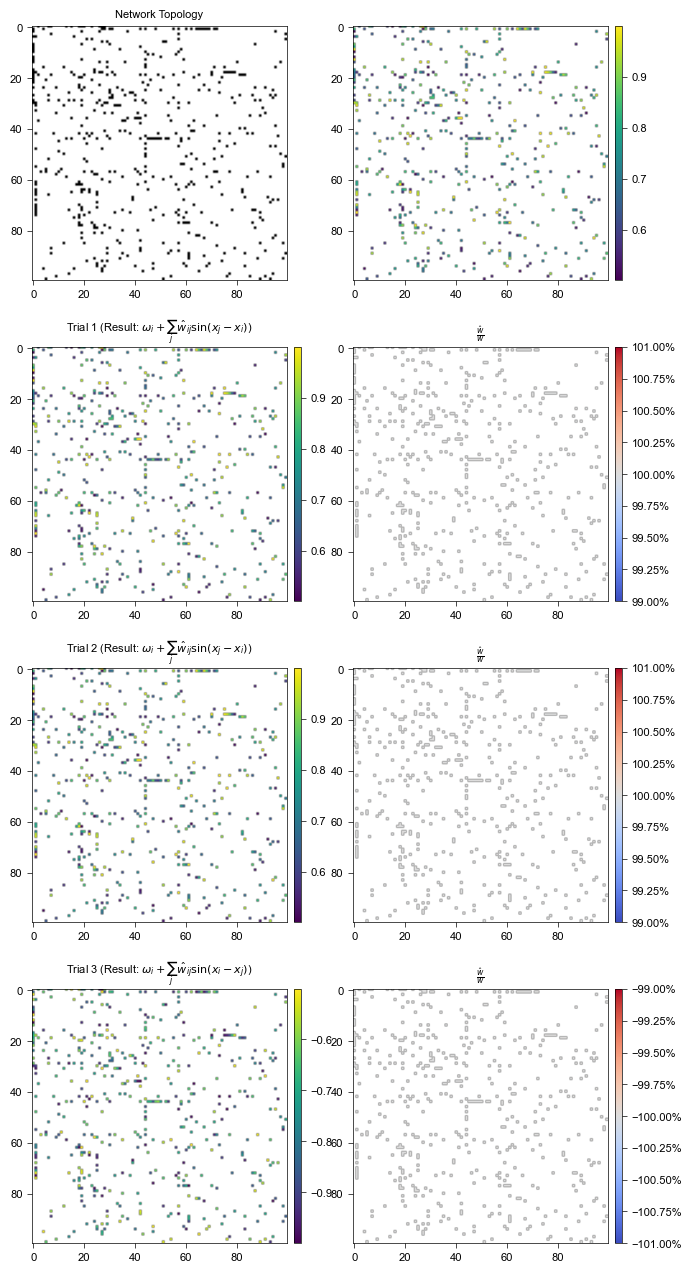

In [43]:
from matplotlib.ticker import PercentFormatter

fi, fig, axes = get_fig(4, 2, FW=18, LM=6, TM=6, BM=6, RM=6, fontsize=8, dpi=100)

ax = axes[0]
ax.imshow(A, cmap='binary')
ax.set_title('Network Topology')

ax = axes[1]
tmp0 = np.full(A.shape, np.nan)
tmp0[G[:, 0], G[:, 1]] = w
ax.imshow(tmp0, cmap='viridis')
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])

ax = axes[2]
tmp = np.full(A.shape, np.nan)
tmp[G[:, 0], G[:, 1]] = np.array(result.loc[0, 'result'][4])
ax.imshow(tmp, cmap='viridis')
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('Trial 1 (Result: $\\omega_i + \\sum_j \\hat{w}_{ij}\\sin(x_j-x_i)$)')

ax = axes[3]
ax.imshow(tmp/tmp0, cmap='coolwarm', vmin=0.99, vmax=1.01)
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('$\\frac{\hat{w}}{w}$')
cax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

ax = axes[4]
tmp = np.full(A.shape, np.nan)
tmp[G[:, 0], G[:, 1]] = np.array(result.loc[1, 'result'][4])
ax.imshow(tmp, cmap='viridis')
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('Trial 2 (Result: $\\omega_i + \\sum_j \\hat{w}_{ij}\\sin(x_j-x_i)$)')

ax = axes[5]
ax.imshow(tmp/tmp0, cmap='coolwarm', vmin=0.99, vmax=1.01)
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('$\\frac{\hat{w}}{w}$')
cax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

ax = axes[6]
tmp = np.full(A.shape, np.nan)
tmp[G[:, 0], G[:, 1]] = np.array(result.loc[2, 'result'][4])
ax.imshow(tmp, cmap='viridis')
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('Trial 3 (Result: $\\omega_i + \\sum_j \\hat{w}_{ij}\\sin(x_i-x_j)$)')

ax = axes[7]
ax.imshow(tmp/tmp0, cmap='coolwarm', vmin=-1.01, vmax=-0.99)
cax = fig.add_axes([ax.get_position().x1+0.01, ax.get_position().y0, 0.01, ax.get_position().height])
plt.colorbar(cax=cax, mappable=ax.images[0])
ax.set_title('$\\frac{\hat{w}}{w}$')
cax.yaxis.set_major_formatter(PercentFormatter(xmax=1))


In [ ]:
dir()

['_INVALID_AFFINE_ONLY',
 '_INVALID_FULL',
 '_VALID',
 '__array__',
 '__class__',
 '__copy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_ignore',
 '_invalid',
 '_invalidate_internal',
 '_minpos',
 '_parents',
 '_points',
 '_points_orig',
 '_shorthand_name',
 'anchored',
 'bounds',
 'coefs',
 'contains',
 'containsx',
 'containsy',
 'corners',
 'count_contains',
 'count_overlaps',
 'expanded',
 'extents',
 'from_bounds',
 'from_extents',
 'frozen',
 'fully_contains',
 'fully_containsx',
 'fully_containsy',
 'fully_overlaps',
 'get_points',
 'height',
 'ignore',
 'intersection',
 'intervalx',
 'intervaly',
 'invalidate',
 'is_affine',
 'is_bbo